In [1]:
# Import libraries

import pandas as pd
import numpy as np

In [2]:
import pandas as pd

df = pd.read_csv(r'C:\Users\czhen\Desktop\loan data\accepted_2007_to_2018Q4.csv.gz', 
                 compression='gzip', low_memory=False)
print("Loaded! Shape:", df.shape)

Loaded! Shape: (2260701, 151)


In [3]:
print(df.shape)
print(df.columns.tolist()[:10])  # print first 10 column names
print(df.head(2))

(2260701, 151)
['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade']
         id  member_id  loan_amnt  funded_amnt  funded_amnt_inv        term  \
0  68407277        NaN     3600.0       3600.0           3600.0   36 months   
1  68355089        NaN    24700.0      24700.0          24700.0   36 months   

   int_rate  installment grade sub_grade  ... hardship_payoff_balance_amount  \
0     13.99       123.03     C        C4  ...                            NaN   
1     11.99       820.28     C        C1  ...                            NaN   

  hardship_last_payment_amount disbursement_method  debt_settlement_flag  \
0                          NaN                Cash                     N   
1                          NaN                Cash                     N   

  debt_settlement_flag_date settlement_status settlement_date  \
0                       NaN               NaN             NaN   
1                      

In [4]:
# First look at the data
print("Shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes.value_counts())

print("\nMissing values (top 20 worst columns):")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
print(missing_df[missing_df['missing_count'] > 0].sort_values('missing_pct', ascending=False).head(20))

Shape: (2260701, 151)

Column names:
['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'url', 'desc', 'purpose', 'title', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d', 'last_fico_range_high', 'last_fico_range_low', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'policy_code', 'application_type', 'annual_inc_joint', 'dti_joint', 'verifica

In [5]:
# Check what loan statuses exist
print(df['loan_status'].value_counts())

loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
Name: count, dtype: int64


In [6]:
# Define default vs non-default
# Drop loan not yet completed statuses
df = df[~df['loan_status'].isin(['Current', 'In Grace Period'])]

# Create target variable: 1 = default, 0 = fully paid
default_statuses = [
    'Charged Off',
    'Late (31-120 days)',
    'Late (16-30 days)',
    'Does not meet the credit policy. Status:Charged Off',
    'Default'
]

df['is_default'] = df['loan_status'].isin(default_statuses).astype(int)

# Check the result
print("Remaining rows:", len(df))
print("\nTarget variable distribution:")
print(df['is_default'].value_counts())
print("\nDefault rate:", round(df['is_default'].mean() * 100, 2), "%")

Remaining rows: 1373948

Target variable distribution:
is_default
0    1078772
1     295176
Name: count, dtype: int64

Default rate: 21.48 %


In [7]:
# Drop columns that are >50% missing or irrelevant
cols_to_drop = [
    # Identifiers — not predictive
    'id', 'member_id', 'url', 'desc', 'title',
    
    # Post-loan outcome columns — these would cause data leakage
    # (the model would be "cheating" by seeing info only available after default)
    'loan_status', 'out_prncp', 'out_prncp_inv', 'total_pymnt',
    'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int',
    'total_rec_late_fee', 'recoveries', 'collection_recovery_fee',
    'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d',

    # Hardship & settlement columns (99%+ missing)
    'hardship_flag', 'hardship_type', 'hardship_reason', 'hardship_status',
    'deferral_term', 'hardship_amount', 'hardship_start_date',
    'hardship_end_date', 'payment_plan_start_date', 'hardship_length',
    'hardship_dpd', 'hardship_loan_status',
    'orig_projected_additional_accrued_interest',
    'hardship_payoff_balance_amount', 'hardship_last_payment_amount',
    'debt_settlement_flag_date', 'settlement_status', 'settlement_date',
    'settlement_amount', 'settlement_percentage', 'settlement_term',

    # Joint application columns (mostly empty)
    'annual_inc_joint', 'dti_joint', 'verification_status_joint',
    'revol_bal_joint', 'sec_app_fico_range_low', 'sec_app_fico_range_high',
    'sec_app_earliest_cr_line', 'sec_app_inq_last_6mths',
    'sec_app_mort_acc', 'sec_app_open_acc', 'sec_app_revol_util',
    'sec_app_open_act_il', 'sec_app_num_rev_accts',
    'sec_app_chargeoff_within_12_mths',
    'sec_app_collections_12_mths_ex_med',
    'sec_app_mths_since_last_major_derog',
]

df = df.drop(columns=cols_to_drop)

print("Remaining columns:", df.shape[1])
print("Remaining rows:", df.shape[0])

Remaining columns: 97
Remaining rows: 1373948


In [8]:
# Default rate by loan grade
grade_default = df.groupby('grade')['is_default'].mean() * 100

print("Default Rate by Loan Grade:")
print(grade_default.round(2))

Default Rate by Loan Grade:
grade
A     6.70
B    14.65
C    24.23
D    32.30
E    40.07
F    46.42
G    51.11
Name: is_default, dtype: float64


C:\Users\czhen\AppData\Local\Temp\ipykernel_32592\3640273513.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=grade_default.index, y=grade_default.values, palette='RdYlGn_r')


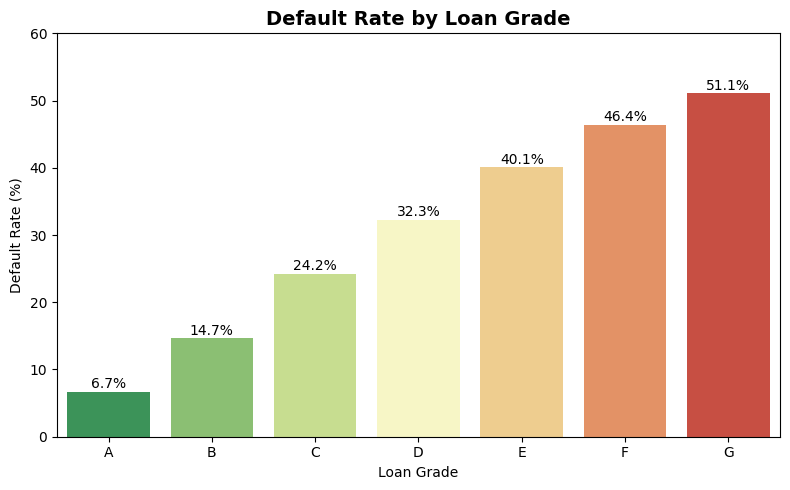

Chart saved to reports folder!


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot default rate by grade
plt.figure(figsize=(8, 5))
sns.barplot(x=grade_default.index, y=grade_default.values, palette='RdYlGn_r')

plt.title('Default Rate by Loan Grade', fontsize=14, fontweight='bold')
plt.xlabel('Loan Grade')
plt.ylabel('Default Rate (%)')
plt.ylim(0, 60)

# Add percentage labels on top of each bar
for i, val in enumerate(grade_default.values):
    plt.text(i, val + 0.5, f'{val:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig(r'C:\Users\czhen\Desktop\loan-default-prediction\reports\default_rate_by_grade.png', dpi=150)
plt.show()

print("Chart saved to reports folder!")

In [10]:
# Default rate by income bracket
# First cut annual income into buckets
df['income_bracket'] = pd.cut(
    df['annual_inc'],
    bins=[0, 30000, 50000, 75000, 100000, 150000, float('inf')],
    labels=['<30k', '30-50k', '50-75k', '75-100k', '100-150k', '150k+']
)

# Calculate default rate per bracket
income_default = df.groupby('income_bracket', observed=True)['is_default'].mean() * 100

print("Default Rate by Income Bracket:")
print(income_default.round(2))

Default Rate by Income Bracket:
income_bracket
<30k        26.01
30-50k      23.90
50-75k      21.96
75-100k     19.76
100-150k    17.82
150k+       16.35
Name: is_default, dtype: float64


C:\Users\czhen\AppData\Local\Temp\ipykernel_32592\2238806555.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=income_default.index, y=income_default.values, palette='RdYlGn_r')


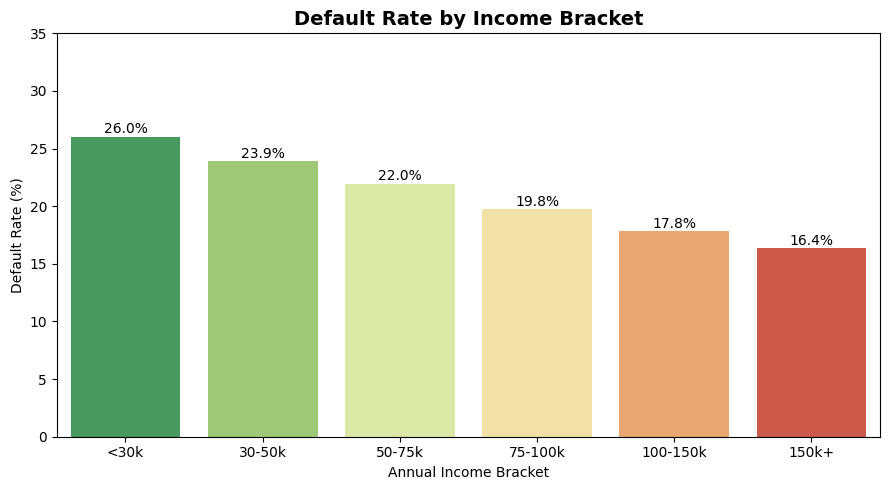

Chart saved!


In [11]:
# Plot default rate by income bracket
plt.figure(figsize=(9, 5))
sns.barplot(x=income_default.index, y=income_default.values, palette='RdYlGn_r')

plt.title('Default Rate by Income Bracket', fontsize=14, fontweight='bold')
plt.xlabel('Annual Income Bracket')
plt.ylabel('Default Rate (%)')
plt.ylim(0, 35)

# Add percentage labels on top of each bar
for i, val in enumerate(income_default.values):
    plt.text(i, val + 0.3, f'{val:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig(r'C:\Users\czhen\Desktop\loan-default-prediction\reports\default_rate_by_income.png', dpi=150)
plt.show()

print("Chart saved!")

In [12]:
print('is_default' in df.columns)
print(df.shape)

True
(1373948, 98)


In [13]:
# Default rate by DTI bucket
df['dti_bucket'] = pd.cut(
    df['dti'],
    bins=[0, 10, 20, 30, 40, float('inf')],
    labels=['0-10', '10-20', '20-30', '30-40', '40+']
)

dti_default = df.groupby('dti_bucket', observed=True)['is_default'].mean() * 100

print("Default Rate by DTI Bucket:")
print(dti_default.round(2))

Default Rate by DTI Bucket:
dti_bucket
0-10     16.43
10-20    19.24
20-30    24.54
30-40    30.80
40+      36.50
Name: is_default, dtype: float64


C:\Users\czhen\AppData\Local\Temp\ipykernel_32592\3211438241.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dti_default.index, y=dti_default.values, palette='RdYlGn_r')


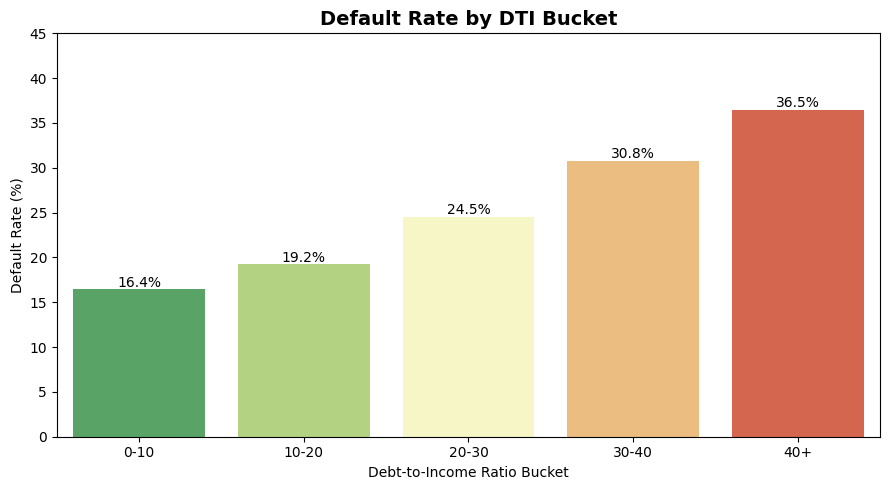

Chart saved!


In [15]:
# Plot default rate by DTI bucket
plt.figure(figsize=(9, 5))
sns.barplot(x=dti_default.index, y=dti_default.values, palette='RdYlGn_r')

plt.title('Default Rate by DTI Bucket', fontsize=14, fontweight='bold')
plt.xlabel('Debt-to-Income Ratio Bucket')
plt.ylabel('Default Rate (%)')
plt.ylim(0, 45)

for i, val in enumerate(dti_default.values):
    plt.text(i, val + 0.3, f'{val:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig(r'C:\Users\czhen\Desktop\loan-default-prediction\reports\default_rate_by_dti.png', dpi=150)
plt.show()

print("Chart saved!")

In [16]:
# Default rate by state
state_default = df.groupby('addr_state')['is_default'].mean() * 100
state_default = state_default.sort_values(ascending=False)

print("Top 10 Highest Default States:")
print(state_default.head(10).round(2))

print("\nTop 10 Lowest Default States:")
print(state_default.tail(10).round(2))

Top 10 Highest Default States:
addr_state
MS    28.69
NE    27.31
AR    25.71
AL    25.29
OK    25.09
LA    24.69
NY    23.76
NV    23.25
FL    23.24
MD    23.16
Name: is_default, dtype: float64

Top 10 Lowest Default States:
addr_state
WY    17.90
SC    17.75
WA    17.05
CO    16.71
WV    16.35
NH    16.10
OR    15.59
ME    15.51
VT    15.44
DC    14.38
Name: is_default, dtype: float64


C:\Users\czhen\AppData\Local\Temp\ipykernel_32592\3638398831.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10.values, y=top10.index, palette='Reds_r', ax=ax1)
C:\Users\czhen\AppData\Local\Temp\ipykernel_32592\3638398831.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bottom10.values, y=bottom10.index, palette='Greens', ax=ax2)


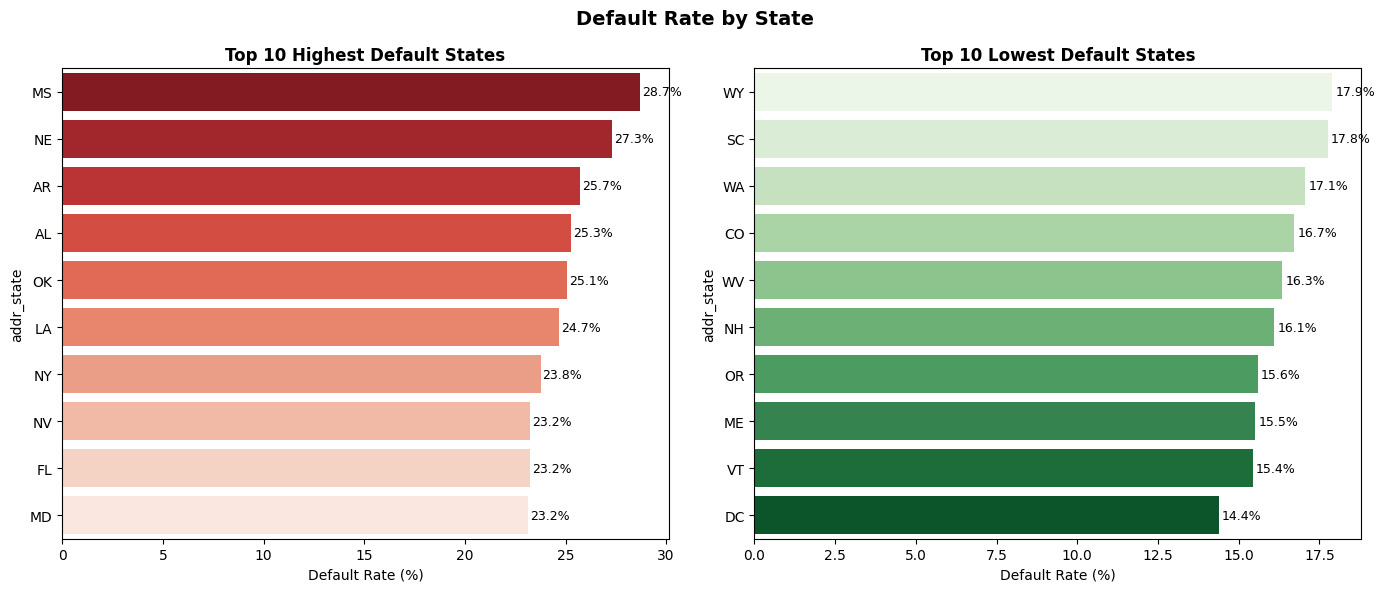

Chart saved!


In [17]:
# Plot default rate by state as a choropleth map
from urllib.request import urlopen
import json

# Create a simple bar chart of top/bottom 10 states
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Top 10 riskiest states
top10 = state_default.head(10)
sns.barplot(x=top10.values, y=top10.index, palette='Reds_r', ax=ax1)
ax1.set_title('Top 10 Highest Default States', fontweight='bold')
ax1.set_xlabel('Default Rate (%)')
for i, val in enumerate(top10.values):
    ax1.text(val + 0.1, i, f'{val:.1f}%', va='center', fontsize=9)

# Top 10 safest states
bottom10 = state_default.tail(10)
sns.barplot(x=bottom10.values, y=bottom10.index, palette='Greens', ax=ax2)
ax2.set_title('Top 10 Lowest Default States', fontweight='bold')
ax2.set_xlabel('Default Rate (%)')
for i, val in enumerate(bottom10.values):
    ax2.text(val + 0.1, i, f'{val:.1f}%', va='center', fontsize=9)

plt.suptitle('Default Rate by State', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(r'C:\Users\czhen\Desktop\loan-default-prediction\reports\default_rate_by_state.png', dpi=150)
plt.show()

print("Chart saved!")

In [18]:
# Feature 1: Average FICO score
df['fico_avg'] = (df['fico_range_low'] + df['fico_range_high']) / 2

print("FICO average sample:")
print(df[['fico_range_low', 'fico_range_high', 'fico_avg']].head())

FICO average sample:
   fico_range_low  fico_range_high  fico_avg
0           675.0            679.0     677.0
1           715.0            719.0     717.0
2           695.0            699.0     697.0
4           695.0            699.0     697.0
5           690.0            694.0     692.0


In [19]:
# Feature 2: Clean employment length (convert text to number), print values to confirm they are not numerical.
print("Employment length unique values:")
print(df['emp_length'].unique())

Employment length unique values:
['10+ years' '3 years' '4 years' '6 years' '7 years' '8 years' '2 years'
 '5 years' '9 years' '< 1 year' '1 year' nan]


In [20]:
# Convert employment length to numeric
emp_length_map = {
    '< 1 year': 0,
    '1 year': 1,
    '2 years': 2,
    '3 years': 3,
    '4 years': 4,
    '5 years': 5,
    '6 years': 6,
    '7 years': 7,
    '8 years': 8,
    '9 years': 9,
    '10+ years': 10
}

df['emp_length_clean'] = df['emp_length'].map(emp_length_map)
df['emp_length_clean'] = df['emp_length_clean'].fillna(-1)

print("Employment length cleaned:")
print(df[['emp_length', 'emp_length_clean']].head(10))

Employment length cleaned:
   emp_length  emp_length_clean
0   10+ years              10.0
1   10+ years              10.0
2   10+ years              10.0
4     3 years               3.0
5     4 years               4.0
6   10+ years              10.0
7   10+ years              10.0
8     6 years               6.0
9   10+ years              10.0
12    3 years               3.0


In [21]:
# Convert loan term (convert "36 months" to 36)
df['term_months'] = df['term'].str.strip().str.extract(r'(\d+)').squeeze().astype(float)

print("Term cleaned:")
print(df[['term', 'term_months']].head())
print("\nUnique values:", df['term_months'].unique())

Term cleaned:
         term  term_months
0   36 months         36.0
1   36 months         36.0
2   60 months         60.0
4   60 months         60.0
5   36 months         36.0

Unique values: [36. 60. nan]


In [22]:
# Feature 4: Credit utilization (how maxed out is the borrower?)
# revol_util is already a percentage - we just need to clean it up
df['revol_util'] = pd.to_numeric(df['revol_util'], errors='coerce')

# Flag high utilization borrowers (over 75% is considered risky)
df['high_utilization'] = (df['revol_util'] > 75).astype(int)

print("Credit utilization sample:")
print(df[['revol_util', 'high_utilization']].head(10))
print("\nHigh utilization rate:", round(df['high_utilization'].mean() * 100, 2), "%")

Credit utilization sample:
    revol_util  high_utilization
0         29.7                 0
1         19.2                 0
2         56.2                 0
4         64.5                 0
5         68.4                 0
6         84.5                 1
7          5.7                 0
8         34.5                 0
9         39.1                 0
12        67.2                 0

High utilization rate: 19.87 %


In [23]:
# Feature 5: Risk tier (combines grade and DTI bucket)
def assign_risk_tier(row):
    high_risk_grades = ['E', 'F', 'G']
    medium_risk_grades = ['C', 'D']
    high_dti = ['30-40', '40+']
    medium_dti = ['20-30']

    if row['grade'] in high_risk_grades and row['dti_bucket'] in high_dti:
        return 'Very High'
    elif row['grade'] in high_risk_grades or row['dti_bucket'] in high_dti:
        return 'High'
    elif row['grade'] in medium_risk_grades or row['dti_bucket'] in medium_dti:
        return 'Medium'
    else:
        return 'Low'

df['risk_tier'] = df.apply(assign_risk_tier, axis=1)

print("Risk tier distribution:")
print(df['risk_tier'].value_counts())

print("\nDefault rate by risk tier:")
print(df.groupby('risk_tier')['is_default'].mean().sort_values(ascending=False).round(4) * 100)

Risk tier distribution:
risk_tier
Medium       698637
Low          427835
High         223588
Very High     23888
Name: count, dtype: int64

Default rate by risk tier:
risk_tier
Very High    50.01
High         34.08
Medium       23.18
Low          10.54
Name: is_default, dtype: float64


In [24]:
# Summary of all engineered features
new_features = ['fico_avg', 'emp_length_clean', 'term_months', 
                'high_utilization', 'risk_tier', 'dti_bucket', 'income_bracket']

print("All engineered features:")
print(df[new_features].head())
print("\nMissing values in engineered features:")
print(df[new_features].isnull().sum())

All engineered features:
   fico_avg  emp_length_clean  term_months  high_utilization risk_tier  \
0     677.0              10.0         36.0                 0    Medium   
1     717.0              10.0         36.0                 0    Medium   
2     697.0              10.0         60.0                 0       Low   
4     697.0               3.0         60.0                 0      High   
5     692.0               4.0         36.0                 0    Medium   

  dti_bucket income_bracket  
0       0-10         50-75k  
1      10-20         50-75k  
2      10-20         50-75k  
4      20-30       100-150k  
5      10-20         30-50k  

Missing values in engineered features:
fico_avg              33
emp_length_clean       0
term_months           33
high_utilization       0
risk_tier              0
dti_bucket          1354
income_bracket       424
dtype: int64


In [25]:
# Check missing values in our key modeling columns
key_cols = ['loan_amnt', 'int_rate', 'annual_inc', 'dti', 
            'fico_avg', 'emp_length_clean', 'term_months', 
            'revol_util', 'high_utilization', 'open_acc', 'pub_rec']

print("Missing values in key columns:")
print(df[key_cols].isnull().sum())

Missing values in key columns:
loan_amnt            33
int_rate             33
annual_inc           37
dti                 436
fico_avg             33
emp_length_clean      0
term_months          33
revol_util          960
high_utilization      0
open_acc             62
pub_rec              62
dtype: int64


In [26]:
# Fill missing values with median for numeric columns
numeric_cols = ['loan_amnt', 'int_rate', 'annual_inc', 'dti',
                'fico_avg', 'term_months', 'revol_util', 
                'open_acc', 'pub_rec']

for col in numeric_cols:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)
    
print("Missing values after filling:")
print(df[numeric_cols].isnull().sum())

Missing values after filling:
loan_amnt      0
int_rate       0
annual_inc     0
dti            0
fico_avg       0
term_months    0
revol_util     0
open_acc       0
pub_rec        0
dtype: int64


In [27]:
# Encode categorical columns
# grade: A=1, B=2, C=3, D=4, E=5, F=6, G=7
grade_map = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}
df['grade_encoded'] = df['grade'].map(grade_map)

# home_ownership: keep most common ones, group rest as OTHER
df['home_ownership'] = df['home_ownership'].replace(
    ['NONE', 'ANY'], 'OTHER'
)

# Convert home_ownership and purpose to dummy variables
df = pd.get_dummies(df, columns=['home_ownership', 'purpose'], drop_first=True)

print("New encoded columns added:")
print([col for col in df.columns if 'home_ownership' in col or 'purpose' in col])
print("\nDataframe shape:", df.shape)

New encoded columns added:
['home_ownership_OTHER', 'home_ownership_OWN', 'home_ownership_RENT', 'purpose_credit_card', 'purpose_debt_consolidation', 'purpose_educational', 'purpose_home_improvement', 'purpose_house', 'purpose_major_purchase', 'purpose_medical', 'purpose_moving', 'purpose_other', 'purpose_renewable_energy', 'purpose_small_business', 'purpose_vacation', 'purpose_wedding']

Dataframe shape: (1373948, 119)


In [28]:
print("Shape:", df.shape)
print("is_default rate:", round(df['is_default'].mean() * 100, 2), "%")
print("is_default in columns:", 'is_default' in df.columns)
print("grade_encoded in columns:", 'grade_encoded' in df.columns)
print("fico_avg in columns:", 'fico_avg' in df.columns)
print("risk_tier in columns:", 'risk_tier' in df.columns)

Shape: (1373948, 119)
is_default rate: 21.48 %
is_default in columns: True
grade_encoded in columns: True
fico_avg in columns: True
risk_tier in columns: True


In [29]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

# Select final features
feature_cols = [
    'loan_amnt', 'int_rate', 'installment', 'term_months', 'grade_encoded',
    'annual_inc', 'dti', 'fico_avg', 'revol_util', 'high_utilization',
    'open_acc', 'pub_rec', 'emp_length_clean',
    'home_ownership_OTHER', 'home_ownership_OWN', 'home_ownership_RENT',
    'purpose_credit_card', 'purpose_debt_consolidation', 'purpose_home_improvement',
    'purpose_house', 'purpose_major_purchase', 'purpose_medical',
    'purpose_moving', 'purpose_other', 'purpose_small_business',
    'purpose_vacation', 'purpose_wedding'
]

X = df[feature_cols]
y = df['is_default']

# Split into 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])
print("Default rate in train:", round(y_train.mean() * 100, 2), "%")
print("Default rate in test:", round(y_test.mean() * 100, 2), "%")

Training rows: 1099158
Testing rows: 274790
Default rate in train: 21.48 %
Default rate in test: 21.48 %


In [30]:
# Find which columns still have NaN values
print("Columns with NaN values:")
print(X_train.isnull().sum()[X_train.isnull().sum() > 0])

Columns with NaN values:
installment      28
grade_encoded    28
dtype: int64


In [31]:
# Fill remaining NaN values in X_train and X_test
X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_test.median())

# Verify
print("Remaining NaNs in X_train:", X_train.isnull().sum().sum())
print("Remaining NaNs in X_test:", X_test.isnull().sum().sum())

Remaining NaNs in X_train: 0
Remaining NaNs in X_test: 0


In [32]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score

# Scale and train
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training Logistic Regression...")
from sklearn.linear_model import LogisticRegression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

y_pred = lr_model.predict(X_test_scaled)
y_prob = lr_model.predict_proba(X_test_scaled)[:, 1]

print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("AUC Score:", round(roc_auc_score(y_test, y_prob), 4))

Training Logistic Regression...

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.98      0.88    215755
           1       0.53      0.09      0.16     59035

    accuracy                           0.79    274790
   macro avg       0.66      0.54      0.52    274790
weighted avg       0.74      0.79      0.72    274790

AUC Score: 0.7041


In [33]:
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest
print("Training Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=100,      # 100 decision trees
    max_depth=10,          # limit tree depth to avoid overfitting
    random_state=42,
    n_jobs=-1              # use all CPU cores to speed it up
)
rf_model.fit(X_train, y_train)

# Evaluate
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))
print("AUC Score:", round(roc_auc_score(y_test, y_prob_rf), 4))

Training Random Forest...

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.99      0.88    215755
           1       0.60      0.05      0.09     59035

    accuracy                           0.79    274790
   macro avg       0.70      0.52      0.48    274790
weighted avg       0.75      0.79      0.71    274790

AUC Score: 0.7094


In [34]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_sm.value_counts().to_dict())

Before SMOTE: {0: 863017, 1: 236141}
After SMOTE: {0: 863017, 1: 863017}


In [35]:
from sklearn.ensemble import RandomForestClassifier

print("Training Random Forest with SMOTE data...")
rf_smote = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf_smote.fit(X_train_sm, y_train_sm)

# Evaluate on ORIGINAL test set (not SMOTE'd)
y_pred_rf_sm = rf_smote.predict(X_test)
y_prob_rf_sm = rf_smote.predict_proba(X_test)[:, 1]

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf_sm))
print("AUC Score:", round(roc_auc_score(y_test, y_prob_rf_sm), 4))

Training Random Forest with SMOTE data...

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.83      0.83    215755
           1       0.38      0.38      0.38     59035

    accuracy                           0.73    274790
   macro avg       0.60      0.60      0.60    274790
weighted avg       0.73      0.73      0.73    274790

AUC Score: 0.6905


In [36]:
from xgboost import XGBClassifier

print("Training XGBoost with SMOTE data...")
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    eval_metric='auc'
)
xgb_model.fit(X_train_sm, y_train_sm)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))
print("AUC Score:", round(roc_auc_score(y_test, y_prob_xgb), 4))

Training XGBoost with SMOTE data...

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.97      0.88    215755
           1       0.54      0.11      0.19     59035

    accuracy                           0.79    274790
   macro avg       0.67      0.54      0.53    274790
weighted avg       0.74      0.79      0.73    274790

AUC Score: 0.7131


In [37]:
from sklearn.metrics import precision_recall_curve
import numpy as np

# Try different thresholds
thresholds = np.arange(0.1, 0.6, 0.05)

print("Threshold | Default Recall | Default Precision | Accuracy")
print("-" * 60)
for thresh in thresholds:
    y_pred_thresh = (y_prob_xgb >= thresh).astype(int)
    from sklearn.metrics import recall_score, precision_score, accuracy_score
    recall = recall_score(y_test, y_pred_thresh)
    precision = precision_score(y_test, y_pred_thresh)
    accuracy = accuracy_score(y_test, y_pred_thresh)
    print(f"{thresh:.2f}      | {recall:.2f}           | {precision:.2f}              | {accuracy:.2f}")

Threshold | Default Recall | Default Precision | Accuracy
------------------------------------------------------------
0.10      | 0.95           | 0.25              | 0.37
0.15      | 0.87           | 0.28              | 0.49
0.20      | 0.75           | 0.32              | 0.60
0.25      | 0.61           | 0.35              | 0.67
0.30      | 0.48           | 0.39              | 0.73
0.35      | 0.36           | 0.43              | 0.76
0.40      | 0.26           | 0.47              | 0.78
0.45      | 0.18           | 0.50              | 0.79
0.50      | 0.11           | 0.54              | 0.79
0.55      | 0.06           | 0.59              | 0.79


In [38]:
import joblib

# Save the XGBoost model and scaler
joblib.dump(xgb_model, r'C:\Users\czhen\Desktop\loan-default-prediction\models\xgb_model.pkl')
joblib.dump(scaler, r'C:\Users\czhen\Desktop\loan-default-prediction\models\scaler.pkl')

print("Models saved")

Models saved


In [39]:
# Make sure everything is loaded:
print("Shape:", df.shape)
print("is_default in columns:", 'is_default' in df.columns)
print("XGBoost model ready:", xgb_model is not None)

Shape: (1373948, 119)
is_default in columns: True
XGBoost model ready: True


In [42]:
import shap

# Create SHAP explainer using our XGBoost model
explainer = shap.TreeExplainer(xgb_model)

# SHAP on a sample of 1000 rows (full dataset would take too long)
X_sample = X_test.sample(1000, random_state=42)

#Calclate SHAP values
shap_values = explainer.shap_values(X_sample)

print("Shape of SHAP values:", shap_values.shape)

Shape of SHAP values: (1000, 27)


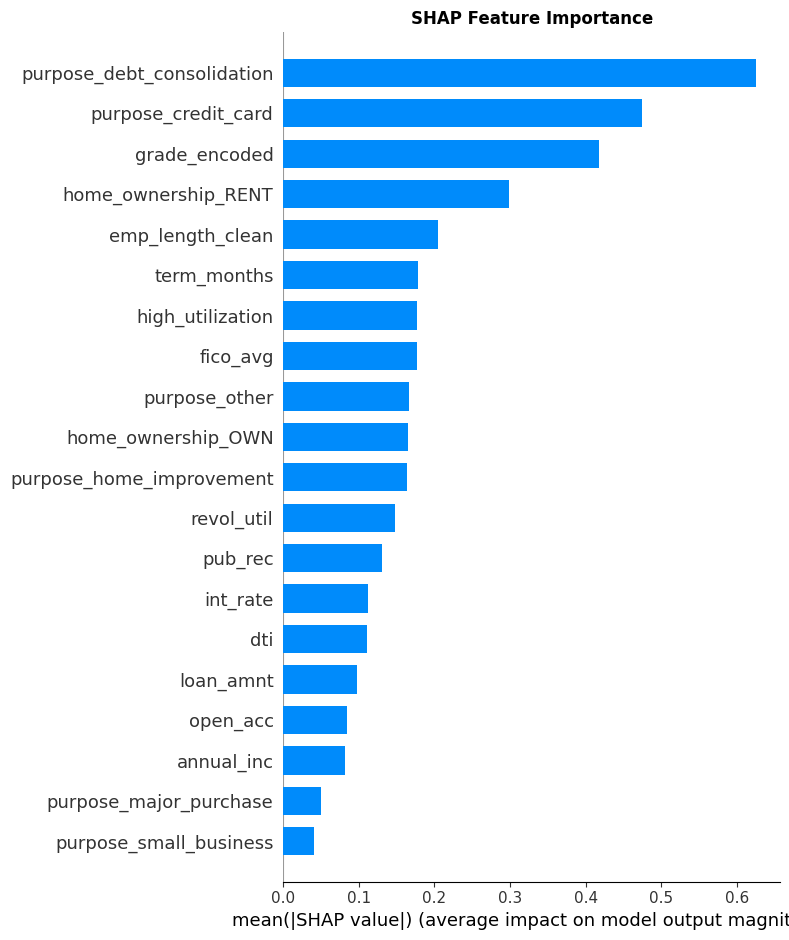

In [43]:
# SHAP Summary Plot — feature importance
plt.figure()
shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False)
plt.title("SHAP Feature Importance", fontweight='bold')
plt.tight_layout()
plt.savefig(r'C:\Users\czhen\Desktop\loan-default-prediction\reports\shap_feature_importance.png', 
            dpi=150, bbox_inches='tight')
plt.show()


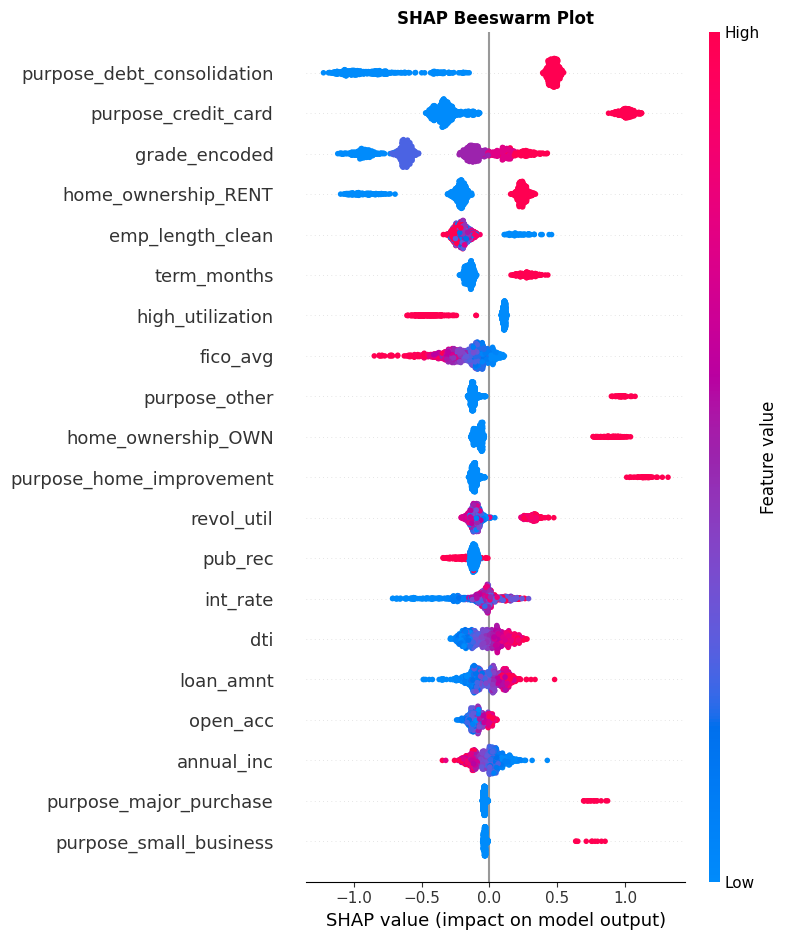

In [44]:
# SHAP Beeswarm Plot
plt.figure()
shap.summary_plot(shap_values, X_sample, show=False)
plt.title("SHAP Beeswarm Plot", fontweight='bold')
plt.tight_layout()
plt.savefig(r'C:\Users\czhen\Desktop\loan-default-prediction\reports\shap_beeswarm.png', 
            dpi=150, bbox_inches='tight')
plt.show()


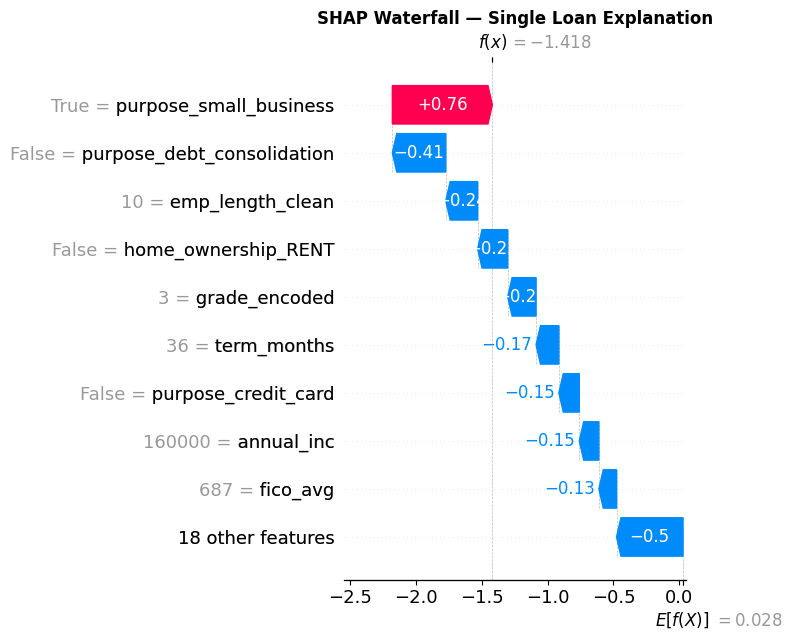

In [45]:
# SHAP Waterfall Plot — explain one individual loan
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0],
        base_values=explainer.expected_value,
        data=X_sample.iloc[0],
        feature_names=X_sample.columns.tolist()
    ),
    show=False
)
plt.title("SHAP Waterfall — Single Loan Explanation", fontweight='bold')
plt.tight_layout()
plt.savefig(r'C:\Users\czhen\Desktop\loan-default-prediction\reports\shap_waterfall.png', 
            dpi=150, bbox_inches='tight')
plt.show()


In [46]:
def threshold_simulator(threshold, y_test, y_prob, avg_loan_amnt=15000, recovery_rate=0.1):
    """
    Simulates business outcomes at a given decision threshold.
    
    threshold: cutoff probability to predict default
    avg_loan_amnt: average loan amount in dollars
    recovery_rate: % of defaulted loan recovered by bank
    """
    y_pred = (y_prob >= threshold).astype(int)
    
    # Confusion matrix components
    TP = ((y_pred == 1) & (y_test == 1)).sum()  # caught defaults
    FP = ((y_pred == 1) & (y_test == 0)).sum()  # good loans rejected
    TN = ((y_pred == 0) & (y_test == 0)).sum()  # good loans approved
    FN = ((y_pred == 0) & (y_test == 1)).sum()  # missed defaults

    # Business metrics
    loans_approved = TN + FN
    loans_rejected = TP + FP
    missed_defaults = FN
    caught_defaults = TP
    money_saved = TP * avg_loan_amnt * (1 - recovery_rate)
    money_lost = FN * avg_loan_amnt * (1 - recovery_rate)
    good_loans_rejected = FP

    print(f"\n{'='*50}")
    print(f"THRESHOLD: {threshold:.2f}")
    print(f"{'='*50}")
    print(f"Loans Approved:          {loans_approved:>10,}")
    print(f"Loans Rejected:          {loans_rejected:>10,}")
    print(f"Defaults Caught:         {caught_defaults:>10,}")
    print(f"Defaults Missed:         {missed_defaults:>10,}")
    print(f"Good Loans Rejected:     {good_loans_rejected:>10,}")
    print(f"Money Saved:             ${money_saved:>12,.0f}")
    print(f"Money Lost to Defaults:  ${money_lost:>12,.0f}")

# Test three thresholds
for t in [0.30, 0.40, 0.50]:
    threshold_simulator(t, y_test, y_prob_xgb)


THRESHOLD: 0.30
Loans Approved:             201,739
Loans Rejected:              73,051
Defaults Caught:             28,439
Defaults Missed:             30,596
Good Loans Rejected:         44,612
Money Saved:             $ 383,926,500
Money Lost to Defaults:  $ 413,046,000

THRESHOLD: 0.40
Loans Approved:             241,359
Loans Rejected:              33,431
Defaults Caught:             15,549
Defaults Missed:             43,486
Good Loans Rejected:         17,882
Money Saved:             $ 209,911,500
Money Lost to Defaults:  $ 587,061,000

THRESHOLD: 0.50
Loans Approved:             262,501
Loans Rejected:              12,289
Defaults Caught:              6,636
Defaults Missed:             52,399
Good Loans Rejected:          5,653
Money Saved:             $  89,586,000
Money Lost to Defaults:  $ 707,386,500


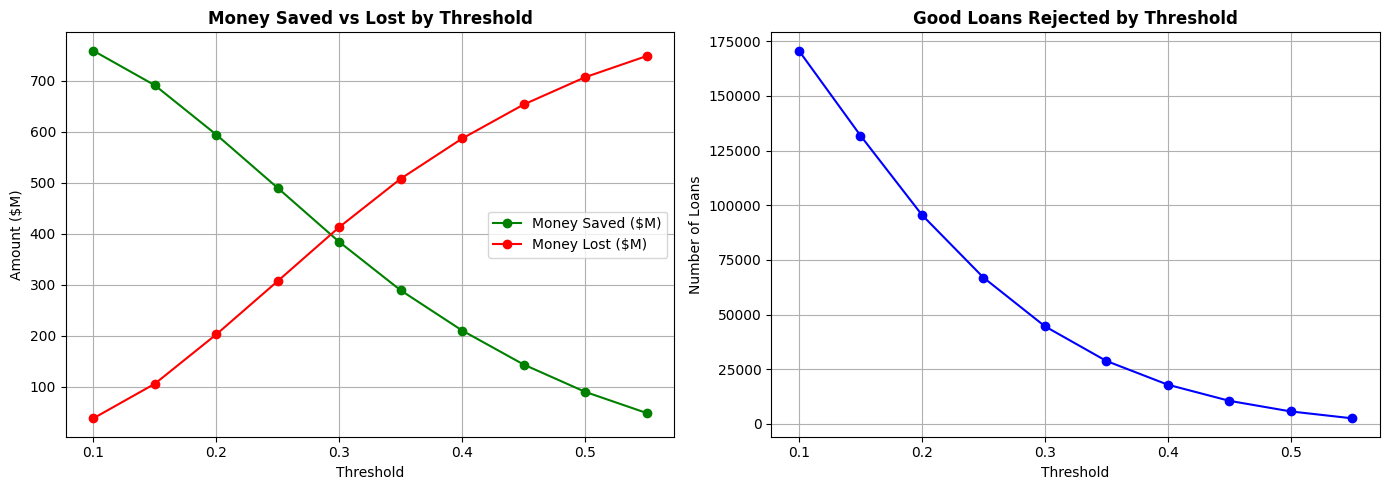

In [47]:
# Visualize threshold tradeoffs
thresholds = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55]
money_saved = []
money_lost = []
good_rejected = []

for t in thresholds:
    y_pred = (y_prob_xgb >= t).astype(int)
    TP = ((y_pred == 1) & (y_test == 1)).sum()
    FP = ((y_pred == 1) & (y_test == 0)).sum()
    FN = ((y_pred == 0) & (y_test == 1)).sum()
    money_saved.append(TP * 15000 * 0.9 / 1e6)
    money_lost.append(FN * 15000 * 0.9 / 1e6)
    good_rejected.append(FP)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Money saved vs lost
ax1.plot(thresholds, money_saved, 'g-o', label='Money Saved ($M)')
ax1.plot(thresholds, money_lost, 'r-o', label='Money Lost ($M)')
ax1.set_xlabel('Threshold')
ax1.set_ylabel('Amount ($M)')
ax1.set_title('Money Saved vs Lost by Threshold', fontweight='bold')
ax1.legend()
ax1.grid(True)

# Plot 2: Good loans rejected
ax2.plot(thresholds, good_rejected, 'b-o')
ax2.set_xlabel('Threshold')
ax2.set_ylabel('Number of Loans')
ax2.set_title('Good Loans Rejected by Threshold', fontweight='bold')
ax2.grid(True)

plt.tight_layout()
plt.savefig(r'C:\Users\czhen\Desktop\loan-default-prediction\reports\threshold_simulator.png', 
            dpi=150, bbox_inches='tight')
plt.show()
